# Fase 2. Análisis exploratorio de Saber 11 (2020-2)

La base elegida en la fase 1 es el resultado anonimizado del examen Saber 11, calendario A, segundo semestre de 2020. Cada fila es un estudiante.

Este cuaderno mira faltantes, valores extremos, distribuciones, relaciones entre variables y tres hipótesis. Con cerca de medio millón de filas un valor p pequeño aparece con efectos diminutos, así que cada prueba se lee con el tamaño del efecto y con las medianas, no solo con el p.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name in {"01_exploracion", "02_eda", "03_preprocesamiento"}:
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
AUDIO = ROOT / "data" / "audio"
FIG = ROOT / "resultados" / "figuras"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

from scipy import stats

PUNTAJES = [
    "PUNT_LECTURA_CRITICA",
    "PUNT_MATEMATICAS",
    "PUNT_C_NATURALES",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_INGLES",
]
COLUMNAS = PUNTAJES + [
    "PUNT_GLOBAL",
    "ESTU_GENERO",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "ESTU_HORASSEMANATRABAJA",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "COLE_JORNADA",
    "COLE_BILINGUE",
    "ESTU_DEPTO_RESIDE",
]

df = pd.read_csv(RAW / "saber11_2020_2.csv", usecols=COLUMNAS, low_memory=False)
df["COLE_BILINGUE"] = df["COLE_BILINGUE"].fillna("No reporta")
print(df.shape)
df.head(3)


(504872, 18)


,ESTU_GENERO,ESTU_DEPTO_RESIDE,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONPADRE,FAMI_EDUCACIONMADRE,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,ESTU_HORASSEMANATRABAJA,COLE_NATURALEZA,COLE_BILINGUE,COLE_AREA_UBICACION,COLE_JORNADA,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,PUNT_GLOBAL
0,F,CUNDINAMARCA,Estrato 2,Técnica o tecnológica completa,Educación profesional completa,Si,Si,0,OFICIAL,N,RURAL,UNICA,54,65,41,33,55.000,244
1,M,CUNDINAMARCA,Estrato 3,Secundaria (Bachillerato) completa,Educación profesional completa,Si,No,Entre 11 y 20 horas,OFICIAL,N,RURAL,NOCHE,57,43,46,49,33.000,238
2,F,CUNDINAMARCA,Estrato 1,Primaria incompleta,Secundaria (Bachillerato) incompleta,No,No,0,OFICIAL,N,RURAL,UNICA,59,72,63,68,59.000,325


## Valores faltantes

`COLE_BILINGUE` ya se marcó como "No reporta": dejarlo vacío o imputar la moda (casi todo es "N") escondería que muchos colegios no respondieron ese campo. El resto de faltantes del cuestionario ronda el 3 %. No se borran esas filas aquí: en preprocesamiento las categóricas pasan a "No responde", para no perder al estudiante que omitió una pregunta.


FAMI_TIENECOMPUTADOR      4.000
ESTU_HORASSEMANATRABAJA   3.360
FAMI_ESTRATOVIVIENDA      3.360
FAMI_TIENEINTERNET        2.710
FAMI_EDUCACIONMADRE       2.670
FAMI_EDUCACIONPADRE       2.570
PUNT_INGLES               0.070
ESTU_GENERO               0.000
ESTU_DEPTO_RESIDE         0.000


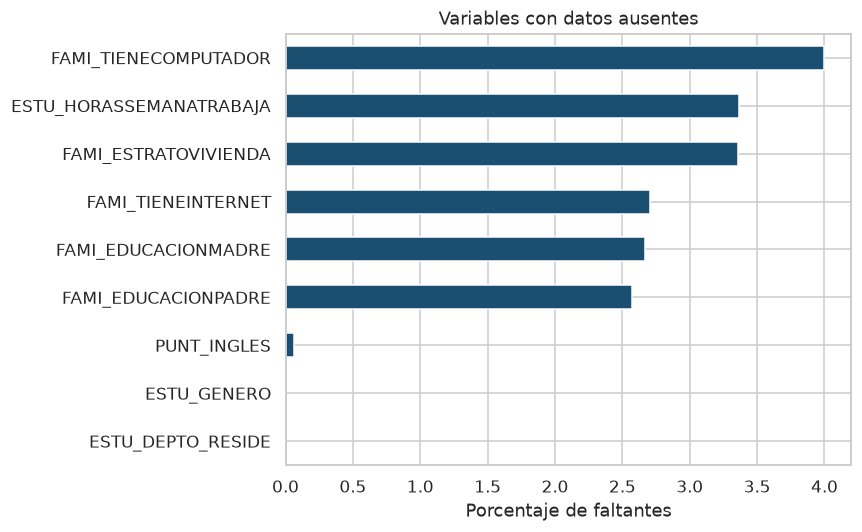

In [2]:
faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print(faltantes.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
faltantes.sort_values().plot.barh(ax=ax, color="#1b4f72")
ax.set_xlabel("Porcentaje de faltantes")
ax.set_title("Variables con datos ausentes")
fig.tight_layout()
fig.savefig(FIG / "02_faltantes.png", bbox_inches="tight")
plt.show()


## Valores atípicos

Se usan dos reglas sobre los puntajes: el rango intercuartílico (vallas a 1,5 IQR) y el z-score con umbral 3. Un puntaje de 0 o de 100 es un resultado posible de la prueba, no un error de sensor. Por eso los extremos se **conservan**: quitarlos recortaría justamente a quien tuvo un desempeño muy bajo o muy alto.


In [3]:
def resumen_atipicos(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = (serie - serie.mean()) / serie.std(ddof=0)
    return {
        "min": serie.min(),
        "max": serie.max(),
        "ceros": int((serie == 0).sum()),
        "fuera_IQR": int(((serie < bajo) | (serie > alto)).sum()),
        "fuera_z3": int((z.abs() > 3).sum()),
        "valla_baja": round(float(bajo), 1),
        "valla_alta": round(float(alto), 1),
    }

atipicos = pd.DataFrame({col: resumen_atipicos(df[col].dropna()) for col in PUNTAJES + ["PUNT_GLOBAL"]}).T
atipicos["pct_IQR"] = (atipicos["fuera_IQR"] / len(df) * 100).round(2)
atipicos


,min,max,ceros,fuera_IQR,fuera_z3,valla_baja,valla_alta,pct_IQR
PUNT_LECTURA_CRITICA,0.000,100.000,197.000,657.000,617.000,24.000,80.000,0.130
PUNT_MATEMATICAS,0.000,100.000,183.000,1627.000,1518.000,19.000,83.000,0.320
PUNT_C_NATURALES,0.000,100.000,392.000,765.000,858.000,16.000,80.000,0.150
PUNT_SOCIALES_CIUDADANAS,0.000,100.000,190.000,1179.000,1179.000,12.000,84.000,0.230
PUNT_INGLES,0.000,100.000,1282.000,21465.000,5114.000,19.500,71.500,4.250
PUNT_GLOBAL,0.000,500.000,80.000,1972.000,1588.000,104.500,388.500,0.390


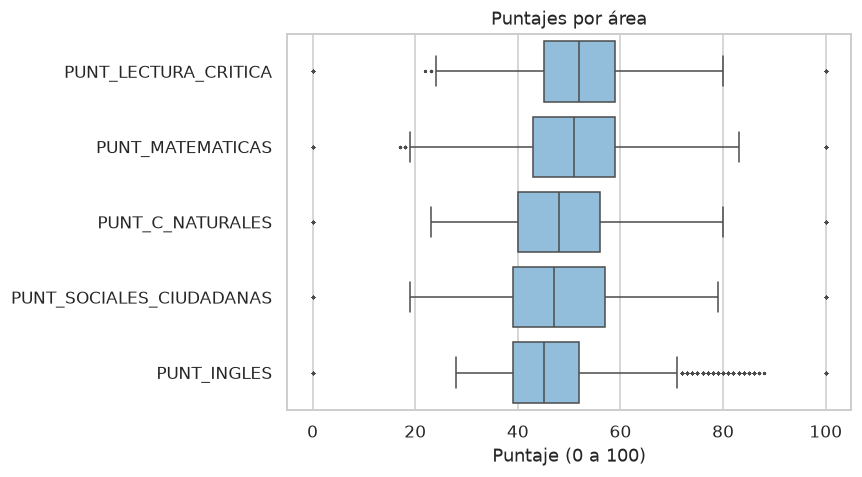

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df[PUNTAJES], orient="h", ax=ax, color="#85c1e9", fliersize=1)
ax.set_title("Puntajes por área")
ax.set_xlabel("Puntaje (0 a 100)")
fig.tight_layout()
fig.savefig(FIG / "02_boxplot_puntajes.png", bbox_inches="tight")
plt.show()


## Distribuciones

Si el sesgo es leve no hace falta un logaritmo. La estandarización se deja para el PCA, porque las áreas van de 0 a 100 y el puntaje global de 0 a 500: sin escalar, el global dominaría cualquier componente.


Puntaje global: media 248.3, mediana 245, sesgo 0.32, curtosis -0.12
Shapiro-Wilk en una muestra de 5000: W=0.987, p=1.85e-21
La prueba sobre toda la base no se usa: con n tan grande rechaza cualquier desviación mínima.


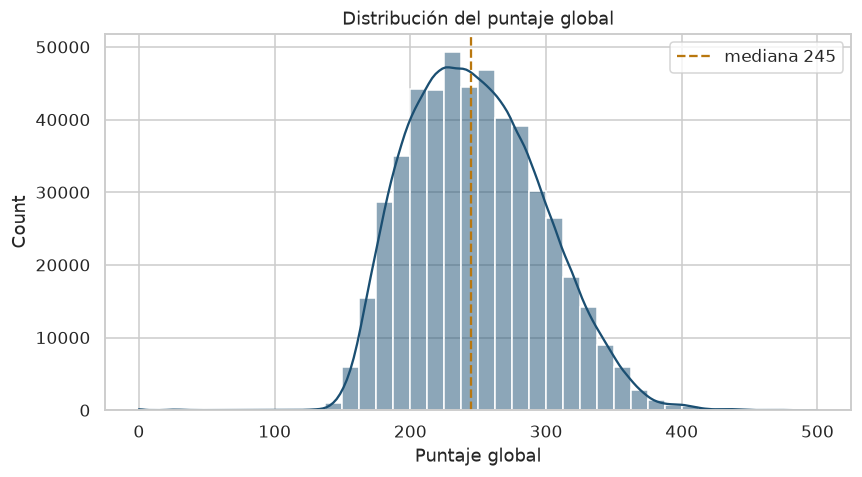

In [5]:
global_ = df["PUNT_GLOBAL"]
sesgo = float(global_.skew())
curtosis = float(global_.kurtosis())
print(f"Puntaje global: media {global_.mean():.1f}, mediana {global_.median():.0f}, sesgo {sesgo:.2f}, curtosis {curtosis:.2f}")
muestra_normalidad = global_.sample(5000, random_state=42)
shapiro_stat, shapiro_p = stats.shapiro(muestra_normalidad)
print(f"Shapiro-Wilk en una muestra de 5000: W={shapiro_stat:.3f}, p={shapiro_p:.3g}")
print("La prueba sobre toda la base no se usa: con n tan grande rechaza cualquier desviación mínima.")

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(global_, bins=40, kde=True, ax=ax, color="#1b4f72")
ax.axvline(global_.median(), color="#b9770e", linestyle="--", label=f"mediana {global_.median():.0f}")
ax.set_title("Distribución del puntaje global")
ax.set_xlabel("Puntaje global")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "02_hist_global.png", bbox_inches="tight")
plt.show()


## Análisis univariado


Género
ESTU_GENERO
F      276572
M      228292
NaN         8

Naturaleza del colegio
COLE_NATURALEZA
OFICIAL       391470
NO OFICIAL    113402

Área
COLE_AREA_UBICACION
URBANO    421978
RURAL      82894

Estrato
FAMI_ESTRATOVIVIENDA
Estrato 1      152852
Estrato 2      182322
Estrato 3      103550
Estrato 4       23463
Estrato 5        7019
Estrato 6        3083
Sin Estrato     15631


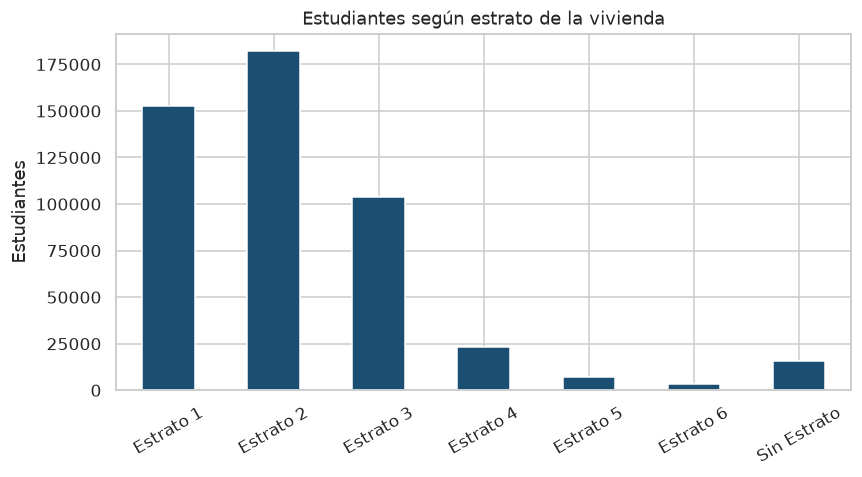

In [6]:
orden_estrato = ["Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6", "Sin Estrato"]
conteo_estrato = df["FAMI_ESTRATOVIVIENDA"].value_counts(dropna=False).reindex(orden_estrato)
print("Género")
print(df["ESTU_GENERO"].value_counts(dropna=False).to_string())
print("\nNaturaleza del colegio")
print(df["COLE_NATURALEZA"].value_counts(dropna=False).to_string())
print("\nÁrea")
print(df["COLE_AREA_UBICACION"].value_counts(dropna=False).to_string())
print("\nEstrato")
print(conteo_estrato.to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
conteo_estrato.plot.bar(ax=ax, color="#1b4f72", rot=30)
ax.set_title("Estudiantes según estrato de la vivienda")
ax.set_ylabel("Estudiantes")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIG / "02_barras_estrato.png", bbox_inches="tight")
plt.show()


In [7]:
descriptivos = df[PUNTAJES + ["PUNT_GLOBAL"]].describe().T
descriptivos["sesgo"] = df[PUNTAJES + ["PUNT_GLOBAL"]].skew()
descriptivos.round(2)


,count,mean,std,min,25%,50%,75%,max,sesgo
PUNT_LECTURA_CRITICA,504872.000,52.160,10.160,0.000,45.000,52.000,59.000,100.000,0.010
PUNT_MATEMATICAS,504872.000,51.020,11.650,0.000,43.000,51.000,59.000,100.000,0.150
PUNT_C_NATURALES,504872.000,48.200,10.500,0.000,40.000,48.000,56.000,100.000,0.260
PUNT_SOCIALES_CIUDADANAS,504872.000,48.230,11.970,0.000,39.000,47.000,57.000,100.000,0.310
PUNT_INGLES,504538.000,46.880,11.310,0.000,39.000,45.000,52.000,100.000,0.860
PUNT_GLOBAL,504872.000,248.350,48.690,0.000,211.000,245.000,282.000,500.000,0.320


## Análisis multivariado

El puntaje global está casi alineado con la suma de las cinco áreas (correlación por encima de 0,99 en esta base). En el PCA se usan las áreas y no el global, para no meter dos veces la misma información.


Correlación entre la suma de las cinco áreas y el puntaje global: 0.994


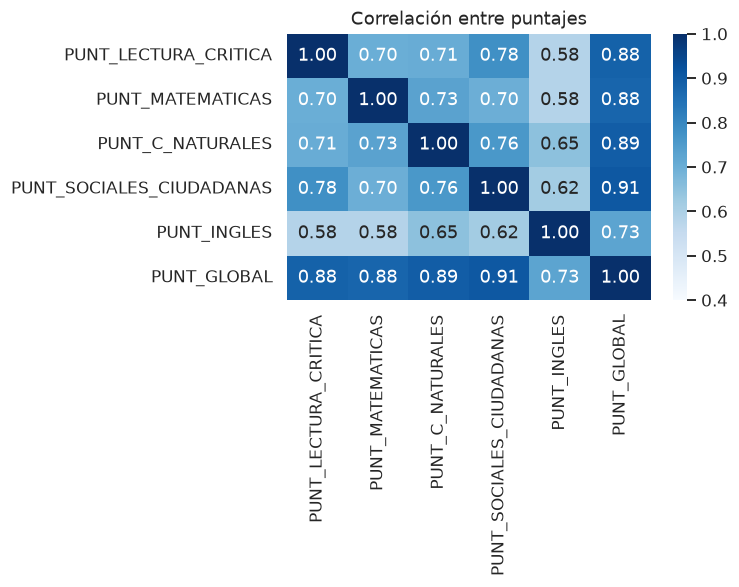

,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,PUNT_GLOBAL
PUNT_LECTURA_CRITICA,1.000,0.701,0.707,0.780,0.584,0.883
PUNT_MATEMATICAS,0.701,1.000,0.732,0.698,0.584,0.877
PUNT_C_NATURALES,0.707,0.732,1.000,0.760,0.648,0.895
PUNT_SOCIALES_CIUDADANAS,0.780,0.698,0.760,1.000,0.616,0.908
PUNT_INGLES,0.584,0.584,0.648,0.616,1.000,0.727
PUNT_GLOBAL,0.883,0.877,0.895,0.908,0.727,1.000


In [8]:
suma_areas = df[PUNTAJES].sum(axis=1, min_count=5)
corr_suma = float(suma_areas.corr(df["PUNT_GLOBAL"]))
print(f"Correlación entre la suma de las cinco áreas y el puntaje global: {corr_suma:.3f}")

corr = df[PUNTAJES + ["PUNT_GLOBAL"]].corr(method="pearson")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0.4, vmax=1, ax=ax)
ax.set_title("Correlación entre puntajes")
fig.tight_layout()
fig.savefig(FIG / "02_correlacion_puntajes.png", bbox_inches="tight")
plt.show()
corr.round(3)


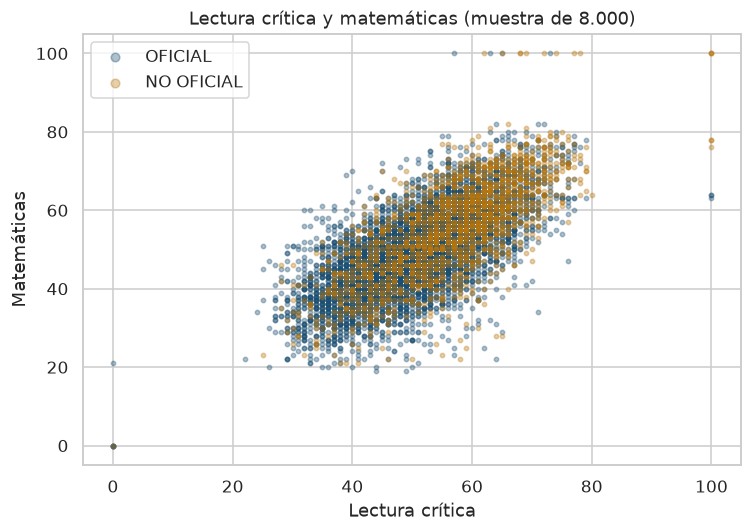

In [9]:
muestra = df.sample(8000, random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
for naturaleza, color in [("OFICIAL", "#1b4f72"), ("NO OFICIAL", "#b9770e")]:
    parte = muestra[muestra["COLE_NATURALEZA"] == naturaleza]
    ax.scatter(
        parte["PUNT_LECTURA_CRITICA"],
        parte["PUNT_MATEMATICAS"],
        s=8,
        alpha=0.35,
        c=color,
        label=naturaleza,
    )
ax.set_xlabel("Lectura crítica")
ax.set_ylabel("Matemáticas")
ax.set_title("Lectura crítica y matemáticas (muestra de 8.000)")
ax.legend(markerscale=2)
fig.tight_layout()
fig.savefig(FIG / "02_dispersion_lectura_matematicas.png", bbox_inches="tight")
plt.show()


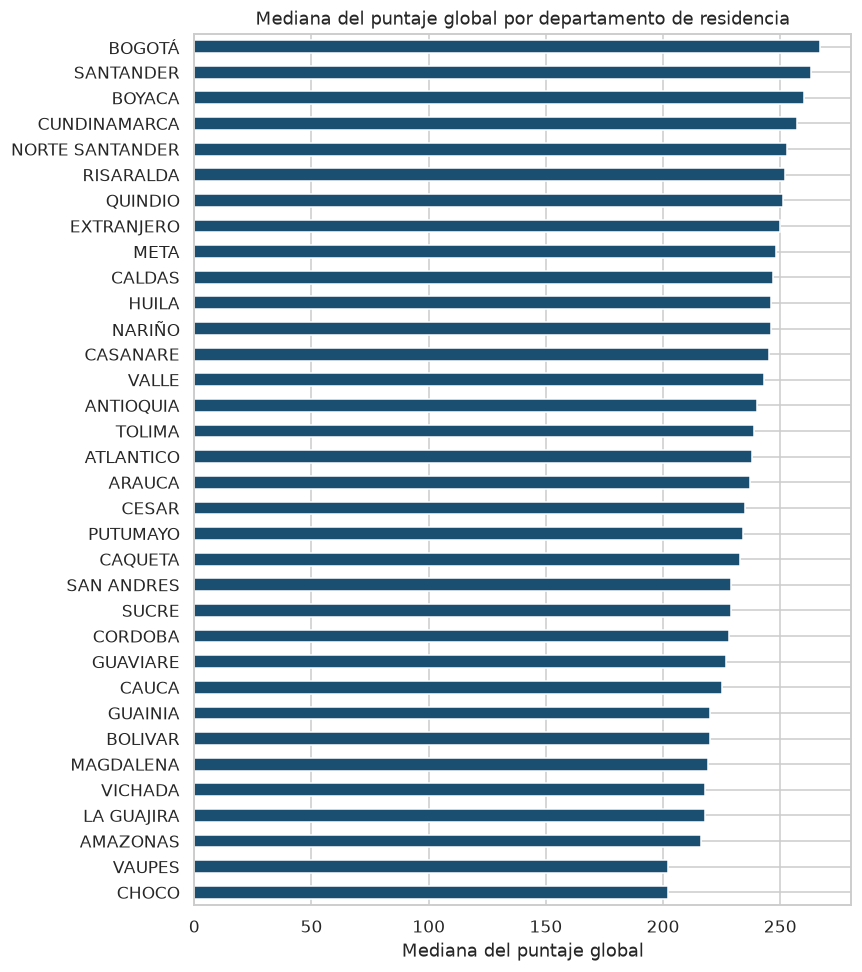

ESTU_DEPTO_RESIDE
CHOCO             202.000
VAUPES            202.000
AMAZONAS          216.000
LA GUAJIRA        218.000
VICHADA           218.000
MAGDALENA         219.000
BOLIVAR           220.000
GUAINIA           220.000
CAUCA             225.000
GUAVIARE          227.000
CORDOBA           228.000
SUCRE             229.000
SAN ANDRES        229.000
CAQUETA           233.000
PUTUMAYO          234.000
CESAR             235.000
ARAUCA            237.000
ATLANTICO         238.000
TOLIMA            239.000
ANTIOQUIA         240.000
VALLE             243.000
CASANARE          245.000
NARIÑO            246.000
HUILA             246.000
CALDAS            247.000
META              248.000
EXTRANJERO        250.000
QUINDIO           251.000
RISARALDA         252.000
NORTE SANTANDER   253.000
CUNDINAMARCA      257.000
BOYACA            260.000
SANTANDER         263.000
BOGOTÁ            267.000


In [10]:
mediana_depto = (
    df.groupby("ESTU_DEPTO_RESIDE")["PUNT_GLOBAL"]
    .median()
    .sort_values()
)
fig, ax = plt.subplots(figsize=(8, 9))
mediana_depto.plot.barh(ax=ax, color="#1b4f72")
ax.set_xlabel("Mediana del puntaje global")
ax.set_ylabel("")
ax.set_title("Mediana del puntaje global por departamento de residencia")
fig.tight_layout()
fig.savefig(FIG / "02_mediana_departamento.png", bbox_inches="tight")
plt.show()
print(mediana_depto.round(0).to_string())


In [11]:
tabla_estrato_naturaleza = pd.crosstab(
    df["FAMI_ESTRATOVIVIENDA"],
    df["COLE_NATURALEZA"],
    normalize="index",
).reindex(orden_estrato)
print("Proporción de naturaleza del colegio dentro de cada estrato")
tabla_estrato_naturaleza.round(3)


Proporción de naturaleza del colegio dentro de cada estrato


COLE_NATURALEZA,NO OFICIAL,OFICIAL
FAMI_ESTRATOVIVIENDA,,
Estrato 1,0.092,0.908
Estrato 2,0.195,0.805
Estrato 3,0.372,0.628
Estrato 4,0.601,0.399
Estrato 5,0.622,0.378
Estrato 6,0.538,0.462
Sin Estrato,0.072,0.928


## Hipótesis

1. El puntaje global no tiene la misma distribución en todos los estratos de la vivienda.
2. El puntaje global difiere entre colegios oficiales y no oficiales.
3. La educación de la madre y el hecho de quedar por encima de la mediana nacional del puntaje global no son independientes.

Se usa Kruskal-Wallis y Mann-Whitney U porque hay grupos y la lectura de normalidad no se da por sentada. El chi-cuadrado contrasta dos categóricas. El tamaño del efecto acompaña cada prueba: épsilon cuadrado, d de Cohen y V de Cramer.


In [12]:
def epsilon_cuadrado(h, n):
    return h * (n + 1) / (n**2 - 1)

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / sp

def cramer_v(tabla):
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.to_numpy().sum()
    r, c = tabla.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

estrato = df.dropna(subset=["FAMI_ESTRATOVIVIENDA", "PUNT_GLOBAL"])
grupos = [g["PUNT_GLOBAL"].to_numpy() for _, g in estrato.groupby("FAMI_ESTRATOVIVIENDA")]
h_stat, h_p = stats.kruskal(*grupos)
eps = epsilon_cuadrado(h_stat, len(estrato))
medianas_estrato = estrato.groupby("FAMI_ESTRATOVIVIENDA")["PUNT_GLOBAL"].median().reindex(orden_estrato)
print("Kruskal-Wallis, puntaje global por estrato")
print(f"H={h_stat:.1f}, p={h_p:.3g}, épsilon²={eps:.4f}, n={len(estrato)}")
print(medianas_estrato.round(0).to_string())

oficial = df.loc[df["COLE_NATURALEZA"] == "OFICIAL", "PUNT_GLOBAL"]
no_oficial = df.loc[df["COLE_NATURALEZA"] == "NO OFICIAL", "PUNT_GLOBAL"]
u_stat, u_p = stats.mannwhitneyu(oficial, no_oficial, alternative="two-sided")
d = cohens_d(no_oficial, oficial)
print("\nMann-Whitney, no oficial frente a oficial")
print(f"U={u_stat:.0f}, p={u_p:.3g}, d de Cohen (no oficial - oficial)={d:.3f}")
print(f"mediana oficial={oficial.median():.0f}, mediana no oficial={no_oficial.median():.0f}")

mapa_educacion = {
    "Ninguno": "Hasta primaria",
    "Primaria incompleta": "Hasta primaria",
    "Primaria completa": "Hasta primaria",
    "Secundaria (Bachillerato) incompleta": "Media",
    "Secundaria (Bachillerato) completa": "Media",
    "Técnica o tecnológica incompleta": "Técnica o tecnológica",
    "Técnica o tecnológica completa": "Técnica o tecnológica",
    "Educación profesional incompleta": "Profesional o postgrado",
    "Educación profesional completa": "Profesional o postgrado",
    "Postgrado": "Profesional o postgrado",
}
educ = df["FAMI_EDUCACIONMADRE"].map(mapa_educacion)
sobre_mediana = np.where(df["PUNT_GLOBAL"] >= df["PUNT_GLOBAL"].median(), "Sobre la mediana", "En o bajo la mediana")
mascara = educ.notna()
tabla = pd.crosstab(educ[mascara], sobre_mediana[mascara])
chi2, chi_p, dof, esperados = stats.chi2_contingency(tabla)
v = cramer_v(tabla)
print("\nChi-cuadrado, educación de la madre y puntaje sobre la mediana")
print(f"chi2={chi2:.1f}, gl={dof}, p={chi_p:.3g}, V de Cramer={v:.3f}")
print(f"Frecuencia esperada mínima: {esperados.min():.1f}")
print("Excluidos por 'No sabe' o sin respuesta:", int((~mascara).sum()))
print(tabla.to_string())


Kruskal-Wallis, puntaje global por estrato
H=33376.2, p=0, épsilon²=0.0684, n=487920
FAMI_ESTRATOVIVIENDA
Estrato 1     233.000
Estrato 2     248.000
Estrato 3     262.000
Estrato 4     277.000
Estrato 5     273.000
Estrato 6     246.000
Sin Estrato   202.000



Mann-Whitney, no oficial frente a oficial
U=15078462776, p=0, d de Cohen (no oficial - oficial)=0.615
mediana oficial=239, mediana no oficial=272



Chi-cuadrado, educación de la madre y puntaje sobre la mediana
chi2=39674.2, gl=3, p=0, V de Cramer=0.287
Frecuencia esperada mínima: 32438.6
Excluidos por 'No sabe' o sin respuesta: 23515
col_0                    En o bajo la mediana  Sobre la mediana
FAMI_EDUCACIONMADRE                                            
Hasta primaria                          87310             42329
Media                                  106379             99449
Profesional o postgrado                 21243             58961
Técnica o tecnológica                   22783             42903


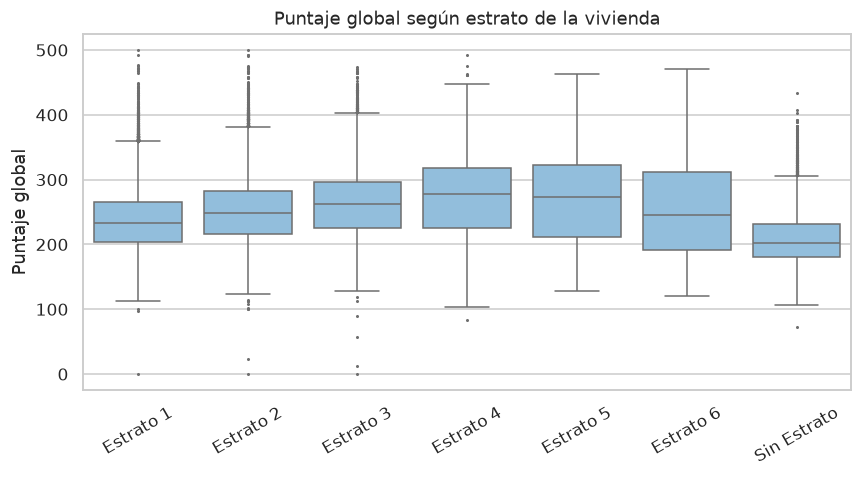

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
orden_plot = [e for e in orden_estrato if e in set(estrato["FAMI_ESTRATOVIVIENDA"])]
sns.boxplot(
    data=estrato,
    x="FAMI_ESTRATOVIVIENDA",
    y="PUNT_GLOBAL",
    order=orden_plot,
    ax=ax,
    color="#85c1e9",
    fliersize=1,
)
ax.set_xlabel("")
ax.set_ylabel("Puntaje global")
ax.set_title("Puntaje global según estrato de la vivienda")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG / "02_global_por_estrato.png", bbox_inches="tight")
plt.show()


In [14]:
horas_orden = {
    "0": 0,
    "Menos de 10 horas": 1,
    "Entre 11 y 20 horas": 2,
    "Entre 21 y 30 horas": 3,
    "Más de 30 horas": 4,
}
horas = df["ESTU_HORASSEMANATRABAJA"].map(horas_orden)
rho, rho_p = stats.spearmanr(horas, df["PUNT_GLOBAL"], nan_policy="omit")
print(f"Spearman, horas de trabajo y puntaje global: rho={rho:.3f}, p={rho_p:.3g}")
medianas_horas = df.assign(horas=horas).dropna(subset=["horas"]).groupby("ESTU_HORASSEMANATRABAJA")["PUNT_GLOBAL"].median()
print(medianas_horas.reindex(horas_orden).round(0).to_string())

lineas = [
    f"El puntaje global tiene media {global_.mean():.1f} y mediana {global_.median():.0f}. El sesgo es {sesgo:.2f}: la forma es cercana a simétrica y no pide una transformación logarítmica.",
    f"Hay {int((df['PUNT_GLOBAL'] == 0).sum())} puntajes globales en cero y {int(atipicos.loc['PUNT_GLOBAL', 'fuera_IQR'])} casos fuera de las vallas IQR ({atipicos.loc['PUNT_GLOBAL', 'pct_IQR']}% ). Se conservan: son resultados de la prueba, no fallas de captura.",
    f"`COLE_BILINGUE` concentra el faltante grande ({(df['COLE_BILINGUE'].eq('No reporta').mean()*100):.1f}% marcado como no reporta). El cuestionario familiar deja cerca del 3 % de celdas vacías. Conviene una categoría explícita de no respuesta, no borrar esas filas.",
    f"La mediana del puntaje global sube del estrato 1 ({medianas_estrato.loc['Estrato 1']:.0f}) al estrato 4 ({medianas_estrato.loc['Estrato 4']:.0f}) y no sigue hasta el estrato 6 ({medianas_estrato.loc['Estrato 6']:.0f}). Sin Estrato es el grupo más bajo ({medianas_estrato.loc['Sin Estrato']:.0f}). Kruskal-Wallis da épsilon²={eps:.3f}: las distribuciones difieren, con un efecto moderado.",
    f"La mediana del colegio no oficial ({no_oficial.median():.0f}) queda por encima de la del oficial ({oficial.median():.0f}), con d={d:.2f}. En el estrato 1, el {tabla_estrato_naturaleza.loc['Estrato 1', 'OFICIAL']*100:.0f}% está en colegio oficial; en el estrato 4, el {tabla_estrato_naturaleza.loc['Estrato 4', 'NO OFICIAL']*100:.0f}% está en colegio no oficial.",
    f"La educación de la madre se asocia con superar la mediana del puntaje (V de Cramer={v:.2f}). Quien reporta madre con educación profesional o de postgrado cae con más frecuencia sobre la mediana.",
    f"Más horas de trabajo a la semana se asocian con un puntaje global más bajo (Spearman rho={rho:.2f}). La relación es débil: trabajar no explica por sí solo el resultado.",
    f"Los cinco puntajes de área se mueven juntos y el global es, en la práctica, su suma (correlación {corr_suma:.3f}). Un modelo que use el global y las áreas a la vez cuenta dos veces el mismo desempeño.",
    f"La mediana departamental no es plana: el extremo bajo de la gráfica y el alto no cuentan la misma historia. El departamento describe contexto; no alcanza para atribuir la diferencia solo al territorio.",
]
hallazgos = ROOT / "02_eda" / "hallazgos.md"
cuerpo = "# Hallazgos del EDA\n\n" + "\n".join(f"- {linea}" for linea in lineas) + "\n"
hallazgos.write_text(cuerpo, encoding="utf-8")
print(cuerpo)


Spearman, horas de trabajo y puntaje global: rho=-0.207, p=0
ESTU_HORASSEMANATRABAJA
0                     255.000
Menos de 10 horas     231.000
Entre 11 y 20 horas   233.000
Entre 21 y 30 horas   237.000
Más de 30 horas       228.000
# Hallazgos del EDA

- El puntaje global tiene media 248.3 y mediana 245. El sesgo es 0.32: la forma es cercana a simétrica y no pide una transformación logarítmica.
- Hay 80 puntajes globales en cero y 1972 casos fuera de las vallas IQR (0.39% ). Se conservan: son resultados de la prueba, no fallas de captura.
- `COLE_BILINGUE` concentra el faltante grande (16.4% marcado como no reporta). El cuestionario familiar deja cerca del 3 % de celdas vacías. Conviene una categoría explícita de no respuesta, no borrar esas filas.
- La mediana del puntaje global sube del estrato 1 (233) al estrato 4 (277) y no sigue hasta el estrato 6 (246). Sin Estrato es el grupo más bajo (202). Kruskal-Wallis da épsilon²=0.068: las distribuciones difieren, con un efecto moderado